# 02. The classical baseline: dynamic harmonic regression with ARIMA errors

A serious classical benchmark for the Bayesian models: the shared design
matrix (local-clock seasonal basis, temperature, dew point, irradiance,
degree days, demand lags, holiday) enters a SARIMAX regression and a
low-order ARMA process carries the residual dynamics. A bare ARIMA on raw
half-hourly demand is deliberately avoided: against two seasonalities and
strong weather dependence it would be a strawman.

The fitted state-space model yields an analytic Gaussian predictive, so
probabilistic scores here use closed forms, which also serve as the
correctness reference for the sample-based estimators scoring the Bayesian
models later. All heavy fitting ran in `scripts/fit_arima.py`; this
notebook reads its artifacts.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from nemforecastdemand.config import load_config
from nemforecastdemand.data.loaders import load_splits
from nemforecastdemand.evaluation.calibration import pit_gaussian, pit_histogram
from nemforecastdemand.evaluation.metrics import (
    crps_gaussian,
    interval_coverage,
    log_score_gaussian,
    mase,
    pinball_loss,
)
from nemforecastdemand.plotting import (
    fan_chart,
    horizon_curve,
    palette,
    save_figure,
    setup_style,
)
from nemforecastdemand.splits import rolling_origins
from nemforecastdemand.utils import load_artifact

setup_style()
cfg = load_config()
splits = load_splits(cfg.paths.processed)
panel = pd.concat([splits["train"], splits["validation"], splits["test"]])
arrays, meta = load_artifact(cfg.paths.artifacts / "arima")

test_origins = rolling_origins(
    splits["test"].index, panel.index, cfg.origins, cfg.horizon, max(cfg.features.demand_lags)
)
assert len(test_origins) == arrays["forecast_mean"].shape[0]

## Order selection and the seasonal basis

Candidate residual orders were fitted on the training split and scored
by mean CRPS over every validation origin (two per day, 00:00 and 12:00
AEST) using the archived weather forecasts, the same conditions as the
headline test evaluation. The final model refits the chosen order on the
full history before the test boundary.

In [2]:
selection = pd.DataFrame(meta["selection"])
selection["order"] = selection["order"].apply(tuple)
selection.set_index("order").round(2)

,val_crps_mw,fit_seconds,llf,aic
order,,,,
"(1, 0, 1)",340.33,140.10,15688.37,-31286.75
"(2, 0, 1)",350.72,208.45,16455.20,-32818.40
"(2, 0, 2)",346.65,227.72,16453.76,-32813.53
"(3, 0, 1)",349.36,194.35,16455.51,-32817.02
"(3, 0, 2)",349.97,218.05,16458.99,-32821.98
"(4, 0, 2)",348.58,223.08,16447.90,-32797.80


The seasonal-basis comparison at the chosen order confirms the model-free
result from notebook 01: trigonometric harmonics and periodic RBFs are
statistically indistinguishable here, so the harmonics stay.

In [3]:
pd.DataFrame(
    {
        "validation CRPS (MW)": meta["basis_scores_mw"],
        "chosen": {b: b == meta["chosen_basis"] for b in meta["basis_scores_mw"]},
    }
).round(1)

,validation CRPS (MW),chosen
fourier,340.3,True
rbf,343.4,False


## Validation calibration

Before scoring the test set, the probability integral transform on the
validation forecasts checks whether the Gaussian predictive is honest
about its own uncertainty. A flat histogram is calibrated; a hump means
the bands are too wide, a U too narrow.

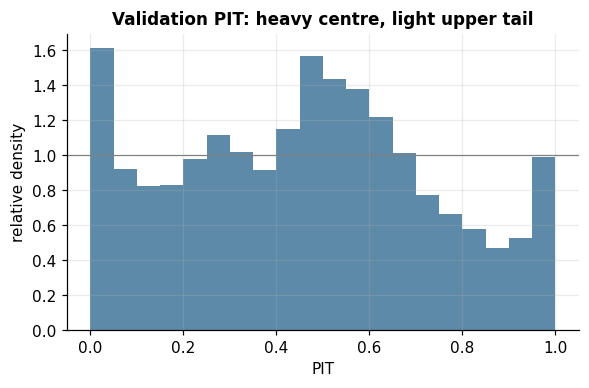

In [4]:
pit = pit_gaussian(arrays["y_val"].ravel(), arrays["val_mean"].ravel(), arrays["val_sd"].ravel())
density, edges = pit_histogram(pit, bins=20)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(edges[:-1], density, width=np.diff(edges), align="edge", color=palette("forecast"))
ax.axhline(1.0, color="grey", lw=0.8)
ax.set_xlabel("PIT")
ax.set_ylabel("relative density")
ax.set_title("Validation PIT: heavy centre, light upper tail")
plt.show()

## Test-set performance under each weather-input variant

The headline row feeds the model the ECMWF forecast exactly as issued one
day ahead. Perfect foresight (ERA5 actuals) bounds how much of the
remaining error is weather; the perturbation rows degrade actuals with
calibrated correlated noise at multiples of the measured forecast error.
The seasonal-naive benchmark anchors everything: its training MAE is also
the scaling base for MASE.

In [5]:
quantiles = np.array(cfg.evaluation.quantiles)
z_quantiles = stats.norm.ppf(quantiles)


def score_variant(mean: np.ndarray, sd: np.ndarray) -> dict[str, float]:
    y = arrays["y_test"]
    crps = crps_gaussian(y, mean, sd)
    quantile_paths = mean[None] + z_quantiles[:, None, None] * sd[None]
    row = {
        "CRPS (MW)": crps.mean(),
        "log score": log_score_gaussian(y, mean, sd).mean(),
        "pinball (MW)": pinball_loss(
            y.ravel(), quantile_paths.reshape(len(quantiles), -1), quantiles
        ).mean(),
        "MAE (MW)": np.abs(y - mean).mean(),
        "MASE": mase(y.ravel(), mean.ravel(), meta["naive_train_mae_mw"]),
    }
    for level in cfg.evaluation.interval_levels:
        z = stats.norm.ppf(0.5 + level / 2)
        row[f"cover {level:.0%}"] = interval_coverage(
            y.ravel(), (mean - z * sd).ravel(), (mean + z * sd).ravel()
        )
    return row


variant_names = ["forecast", "actual"] + [
    f"perturb_{m:g}" for m in cfg.perturbation.sweep_multipliers if m > 0
]
rows = {name: score_variant(arrays[f"{name}_mean"], arrays[f"{name}_sd"]) for name in variant_names}
rows["seasonal naive"] = score_variant(arrays["naive_mean"], arrays["naive_sd"])
scores = pd.DataFrame(rows).T
scores.round(3)

,CRPS (MW),log score,pinball (MW),MAE (MW),MASE,cover 50%,cover 80%,cover 95%
forecast,267.368,7.582,111.993,353.508,0.443,0.665,0.874,0.953
actual,260.402,7.559,109.377,341.329,0.428,0.676,0.881,0.957
perturb_0.5,260.643,7.559,109.380,342.460,0.429,0.677,0.881,0.959
perturb_1,262.552,7.569,110.031,344.936,0.432,0.673,0.873,0.958
perturb_1.5,269.443,7.597,112.345,360.390,0.452,0.635,0.872,0.952
perturb_2,277.412,7.644,115.858,367.967,0.461,0.635,0.851,0.947
seasonal naive,371.669,7.906,161.541,445.357,0.558,0.822,0.969,0.995


Three observations worth carrying forward. First, the model beats the
seasonal naive by more than a hundred megawatts of CRPS, so the
machinery is earning its keep. Second, perfect foresight buys only a
modest improvement over the archived forecast (267 against 260 MW): at
one day ahead, ECMWF weather error is a minor part of the
demand-forecast error budget. Third, the bands over-cover at the centre
(the 50% interval catches two thirds of outcomes) while the tails sit
at nominal: one variance for all hours has to be wide enough for the
evening peak, so it is too wide for the small hours. That centre-tail
mismatch is precisely the opening for the heteroskedastic BSTS.

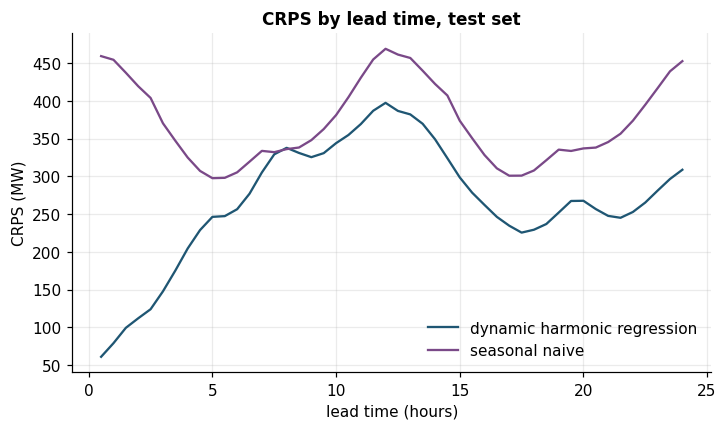

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4))
crps_headline = crps_gaussian(arrays["y_test"], arrays["forecast_mean"], arrays["forecast_sd"])
crps_naive = crps_gaussian(arrays["y_test"], arrays["naive_mean"], arrays["naive_sd"])
horizon_curve(ax, crps_headline, "dynamic harmonic regression", palette("demand"))
horizon_curve(ax, crps_naive, "seasonal naive", palette("accent"))
ax.set_ylabel("CRPS (MW)")
ax.set_title("CRPS by lead time, test set")
ax.legend()
save_figure(fig, "arima_horizon_crps", cfg.paths.figures)
plt.show()

Error grows with lead time as the ARMA state decays towards the
regression, then eases late in the horizon where the overnight trough is
intrinsically easier. The two daily origins tell the same story from
different clocks.

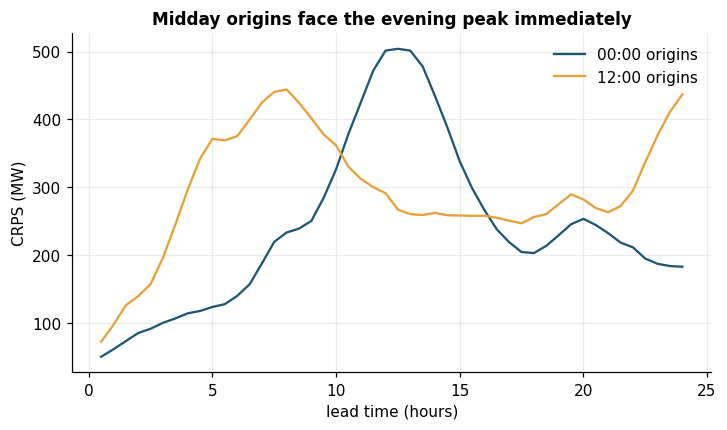

In [7]:
market_hour = test_origins.tz_convert("Australia/Brisbane").hour
fig, ax = plt.subplots(figsize=(7.5, 4))
for hour, colour in ((0, palette("demand")), (12, palette("irradiance"))):
    horizon_curve(ax, crps_headline[market_hour == hour], f"{hour:02d}:00 origins", colour)
ax.set_ylabel("CRPS (MW)")
ax.set_title("Midday origins face the evening peak immediately")
ax.legend()
plt.show()

## What a forecast looks like

A typical day and the worst day of the test set, with central 50/80/95%
bands. The worst day is where the variance story matters most, and it is
kept for the cross-model case study in notebook 05.

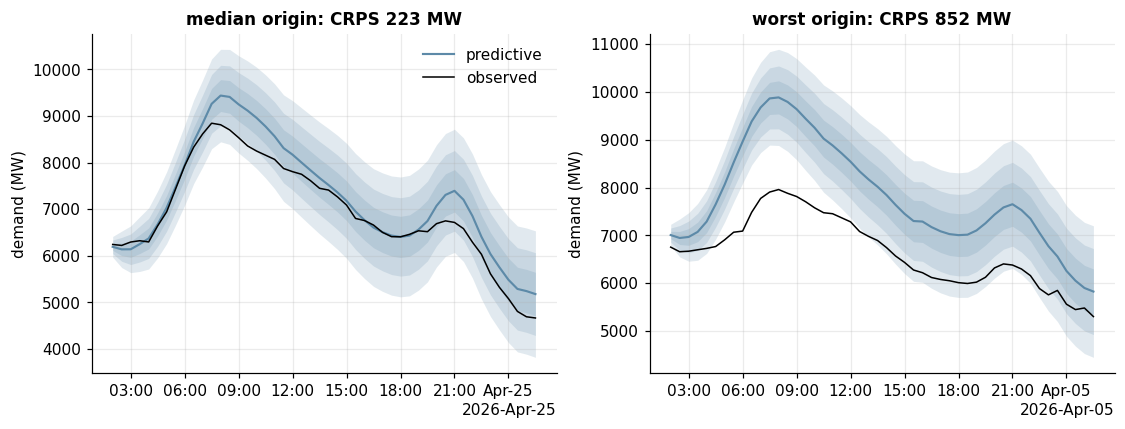

In [8]:
daily_crps = crps_headline.mean(axis=1)
typical = int(np.argsort(daily_crps)[len(daily_crps) // 2])
worst = int(daily_crps.argmax())

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, origin_pos, title in (
    (axes[0], typical, "median origin"),
    (axes[1], worst, "worst origin"),
):
    origin = test_origins[origin_pos]
    index = pd.date_range(origin, periods=cfg.horizon, freq="30min")
    fan_chart(
        ax,
        index,
        mean=arrays["forecast_mean"][origin_pos],
        sd=arrays["forecast_sd"][origin_pos],
        colour=palette("forecast"),
        label="predictive",
    )
    ax.plot(
        index.tz_convert("Australia/Brisbane"),
        arrays["y_test"][origin_pos],
        color="black",
        lw=1.0,
        label="observed",
    )
    ax.set_title(f"{title}: CRPS {daily_crps[origin_pos]:.0f} MW")
    ax.set_ylabel("demand (MW)")
axes[0].legend()
save_figure(fig, "arima_fan_charts", cfg.paths.figures)
plt.show()

## Cost

Fit and forecast wall-clock, as recorded by the fitting script. The
Bayesian notebooks will put these numbers in context: this baseline is
the cheapest serious model in the comparison.

In [9]:
pd.Series(
    {
        "final fit (s)": meta["timings_seconds"]["final_fit"],
        "forecast per origin (s)": meta["forecast_seconds_per_origin"],
        "exogenous columns": meta["n_exog"],
        "chosen order": str(tuple(meta["chosen_order"])),
    }
).to_frame("value")

,value
final fit (s),204.512077
forecast per origin (s),0.092981
exogenous columns,41
chosen order,"(1, 0, 1)"


## Summary

- ARMA(1,1) residuals on top of the shared regression won order selection;
  richer orders add parameters, not validation skill.
- The trigonometric and RBF seasonal bases tie, confirming notebook 01;
  the harmonics remain the project default.
- The baseline beats the seasonal naive decisively (267 against 372 MW
  CRPS) and loses little when moving from perfect-foresight weather to
  the real archived forecast.
- A single Gaussian variance has to average over easy small hours and
  hard evening peaks alike, so it over-covers at the centre even with
  nominal tails; a covariate-driven variance is precisely the opening
  the heteroskedastic BSTS exploits.